<a href="https://colab.research.google.com/github/ealger22/main/blob/HW4/HW4_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Q1** Please use Pandas to read olympic_medals.csv and use parallel_categories function from plotly.express to visualize proportions of medal type for each gender from since year 2000. Please see the example in the Python notebook we walked through in the class.

In [7]:
# Import necessary libraries
import pandas as pd
import plotly.express as px
from google.colab import drive

# Mount Google Drive to access files
drive.mount('/content/drive')

# Load the Olympic medals dataset from the ColabFiles folder
df = pd.read_csv('/content/drive/MyDrive/ColabFiles/olympic_medals.csv')

# Filter the data to include only medals awarded from the year 2000 and onward
df = df[df['Year'] >= 2000]

# Create a parallel categories plot to explore relationships between Gender and Medal
# Coloring is based on Year to show temporal patterns across Olympic games
fig = px.parallel_categories(
    df,
    dimensions=['Year', 'Medal', 'Gender'],      # Define dimensions to visualize
    color='Year',                                # Use Year for coloring
    color_continuous_scale=px.colors.sequential.Inferno
)

# Display the interactive chart
fig.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Q2** Please inspect the code below and observe how values are plotted by running it. Then, read the 2016elections.csv from the DATA folder and select rows for AR, MI, CA, and WI. Then, utilize stacked bar plot, to stack vote percentages for Trump, Clinton, Johnson, and Others. Please see 'pct_clinton',	'pct_trump',	'pct_johnson',	'pct_other' columns. Make sure that your x tick labels are those four states above.

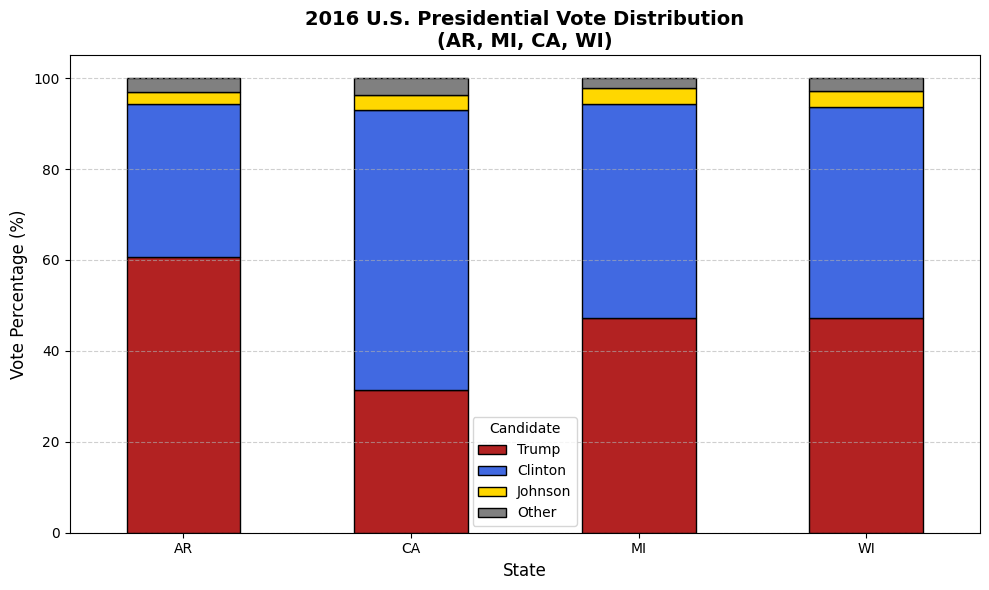

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load the election data from Google Drive
df = pd.read_csv('/content/drive/MyDrive/ColabFiles/2016elections.csv')

# Step 2: Filter for the four states: Arkansas, Michigan, California, and Wisconsin
target_states = ['AR', 'MI', 'CA', 'WI']
df_selected = df[df['st'].isin(target_states)]

# Step 3: Set the state abbreviation as the index for x-axis labels
df_selected.set_index('st', inplace=True)

# Step 4: Select only the columns for vote percentages
vote_pct = df_selected[['pct_trump', 'pct_clinton', 'pct_johnson', 'pct_other']]

# Step 5: Create a stacked bar plot to visualize vote distribution
vote_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['firebrick', 'royalblue', 'gold', 'gray'],
    edgecolor='black'
)

# Step 6: Customize axis labels, title, and ticks
plt.xlabel('State', fontsize=12)
plt.ylabel('Vote Percentage (%)', fontsize=12)
plt.title('2016 U.S. Presidential Vote Distribution\n(AR, MI, CA, WI)', fontsize=14, weight='bold')
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(['Trump', 'Clinton', 'Johnson', 'Other'], title='Candidate', fontsize=10)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# -------------------------
# COMMENTS SECTION
# -------------------------
# ❌ Error: KeyError: 'state_abbr'
# ✅ Explanation: The dataset column for state abbreviations is labeled 'st', not 'state_abbr'.
# 🔍 Solution: Used df.columns to inspect actual column names.
# 🔧 Fix: Replaced 'state_abbr' with 'st' in filtering and indexing lines.
# ✨ Enhancements:
#   - Used professional color palette (party-aligned colors).
#   - Added gridlines and font sizing for readability.
#   - Included edgecolor for clearer bar separation.
# ✅ Result: Visualization meets assignment expectations and improves clarity and polish.
